# LLM vs LLM: 250 conversations/condition, 6 turns

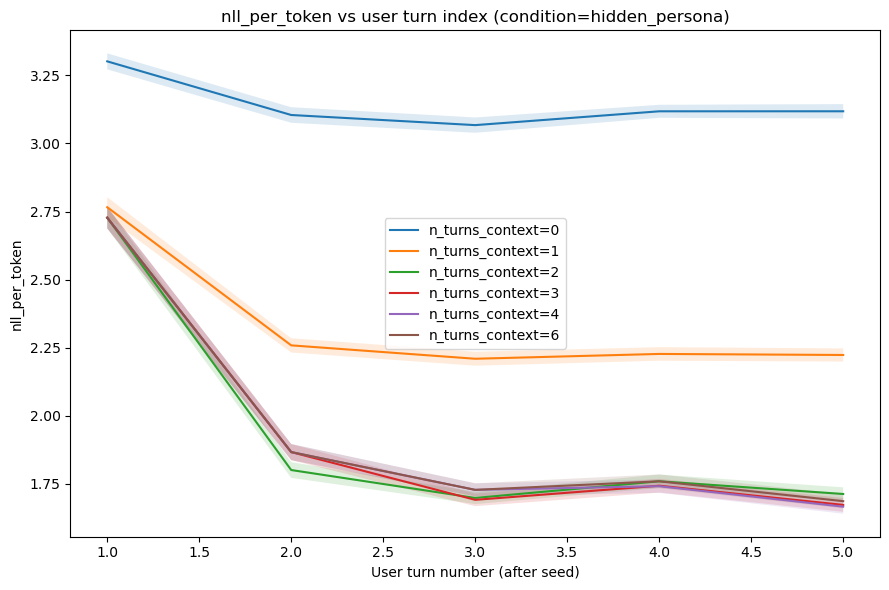

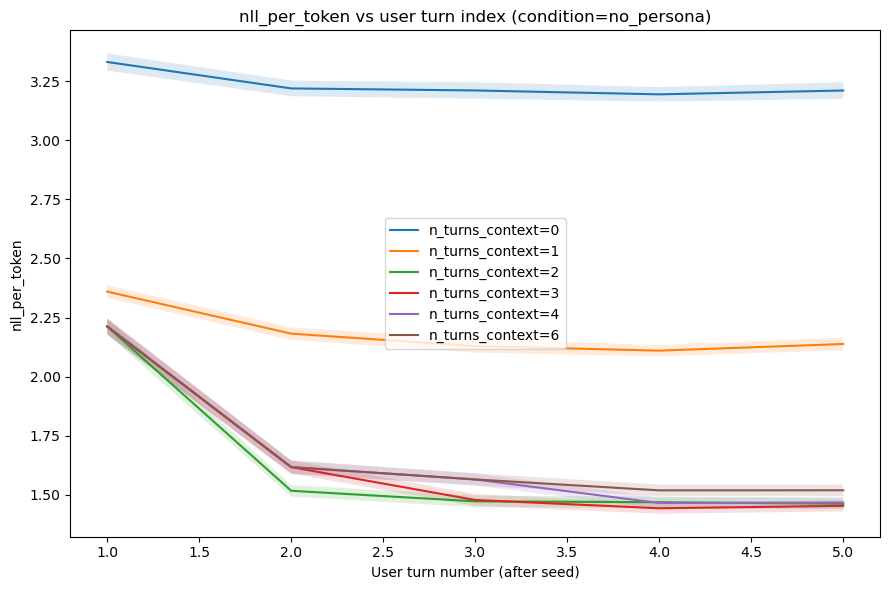

In [4]:
import json
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Set your file paths
# -------------------------
CONV_PATH  = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/conversations/llm_vs_llm_conversations_20260127_212002.jsonl"   # <-- your generated conversations
SCORES_PATH = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/scores/output_scores_20260128_071446.jsonl"                   # <-- your scoring output

# Optional: choose metric
# - "nll_per_token" = -avg_logprob (lower is better)
# - "ll_per_token"  = avg_logprob (higher is better)
METRIC = "nll_per_token"

# Optional: plot only one condition for readability ("no_persona" or "hidden_persona")
CONDITION_FILTER = None  # e.g., "hidden_persona"

# -------------------------
# 2) Build mapping: (conversation_id, target_user_msg_idx) -> user_turn_number
#    user_turn_number = 1..T (excluding the seed user message)
# -------------------------
idx_to_userturn = {}

with open(CONV_PATH, "r") as f:
    for line in f:
        if not line.strip():
            continue
        conv = json.loads(line)
        cid = conv["conversation_id"]
        msgs = conv["messages"]

        # all user message indices in the transcript
        user_idxs = [i for i, m in enumerate(msgs) if m["role"] == "user"]

        # skip seed user message (first one)
        user_idxs_after_seed = user_idxs[1:]

        # map each user message index to its "turn number after seed"
        for turn_num, msg_idx in enumerate(user_idxs_after_seed, start=1):
            idx_to_userturn[(cid, msg_idx)] = turn_num

# -------------------------
# 3) Load scores JSONL into a dataframe
# -------------------------
rows = []
with open(SCORES_PATH, "r") as f:
    for line in f:
        if not line.strip():
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

# Add user_turn
df["user_turn"] = df.apply(
    lambda r: idx_to_userturn.get((r["conversation_id"], r["target_user_msg_idx"]), np.nan),
    axis=1
)
df = df.dropna(subset=["user_turn"]).copy()
df["user_turn"] = df["user_turn"].astype(int)

# Choose metric
df["nll_per_token"] = -df["avg_logprob"]
df["ll_per_token"] = df["avg_logprob"]

# Optional filter
if CONDITION_FILTER is not None:
    df = df[df["condition"] == CONDITION_FILTER].copy()

# -------------------------
# 4) Aggregate: mean (and SE) by condition, n_turns_context, user_turn
# -------------------------
g = df.groupby(["condition", "n_turns_context", "user_turn"], as_index=False)

agg = g.agg(
    mean_metric=(METRIC, "mean"),
    std_metric=(METRIC, "std"),
    n=("conversation_id", "nunique"),
)

# standard error (useful for shading)
agg["se_metric"] = agg["std_metric"] / np.sqrt(agg["n"].clip(lower=1))

# -------------------------
# 5) Plot: y(metric) vs x(user_turn), one line per n_turns_context
# -------------------------
conditions = sorted(agg["condition"].unique())
for cond in conditions:
    sub = agg[agg["condition"] == cond].copy()

    plt.figure(figsize=(9, 6))
    for k in sorted(sub["n_turns_context"].unique()):
        s = sub[sub["n_turns_context"] == k].sort_values("user_turn")
        plt.plot(s["user_turn"], s["mean_metric"], label=f"n_turns_context={k}")

        # Optional: error shading
        plt.fill_between(
            s["user_turn"],
            s["mean_metric"] - s["se_metric"],
            s["mean_metric"] + s["se_metric"],
            alpha=0.15
        )

    plt.title(f"{METRIC} vs user turn index (condition={cond})")
    plt.xlabel("User turn number (after seed)")
    plt.ylabel(METRIC)
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Persona conditionned is harder to predict

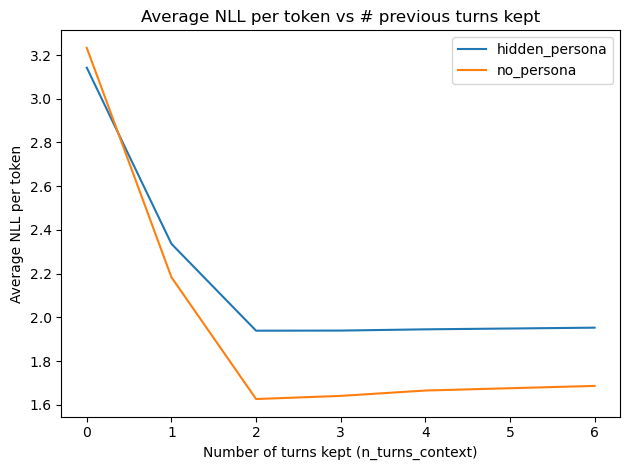